# Flight Delay Prediction - Data Exploration

## Objective
The purpose of this notebook is to explore and understand the dataset used for flight delay prediction.

We will:
- Understand dataset structure
- Analyze feature distributions
- Examine class imbalance
- Identify missing values
- Extract useful insights for feature engineering


### Step 1 : Import Required Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Step 2 : Load the Dataset

In [59]:
df = pd.read_csv("/content/Flight_delay.csv")

In [60]:
df.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


### Step 3 : Dataset Overview

In [61]:
#Shape
df.shape

(484551, 29)

In [62]:
#column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DayOfWeek          484551 non-null  int64 
 1   Date               484551 non-null  object
 2   DepTime            484551 non-null  int64 
 3   ArrTime            484551 non-null  int64 
 4   CRSArrTime         484551 non-null  int64 
 5   UniqueCarrier      484551 non-null  object
 6   Airline            484551 non-null  object
 7   FlightNum          484551 non-null  int64 
 8   TailNum            484551 non-null  object
 9   ActualElapsedTime  484551 non-null  int64 
 10  CRSElapsedTime     484551 non-null  int64 
 11  AirTime            484551 non-null  int64 
 12  ArrDelay           484551 non-null  int64 
 13  DepDelay           484551 non-null  int64 
 14  Origin             484551 non-null  object
 15  Org_Airport        483374 non-null  object
 16  Dest               4

In [63]:
#Statistical Summary
df.describe()

,DayOfWeek,DepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.0,484551.0,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000
mean,3.991605,1564.477865,1617.784438,1652.129929,2139.207386,134.810422,131.400761,108.877134,60.907764,57.498086,752.142689,6.782413,19.150876,0.0,0.0,17.419440,3.153284,13.599421,0.082033,26.653587
std,1.971466,452.235219,583.637660,466.096216,1812.677071,74.070374,71.542531,70.113513,56.975420,55.991012,571.631124,5.555816,15.309747,0.0,0.0,39.417893,19.503657,31.454655,1.884774,40.535994
min,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,-21.000000,0.000000,15.000000,6.000000,31.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1234.000000,1327.000000,1339.000000,629.000000,80.000000,79.000000,57.000000,25.000000,23.000000,331.000000,4.000000,11.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1620.000000,1737.000000,1723.000000,1514.000000,116.000000,114.000000,90.000000,42.000000,40.000000,599.000000,5.000000,15.000000,0.0,0.0,2.000000,0.000000,1.000000,0.000000,13.000000
75%,6.000000,1928.000000,2049.000000,2025.000000,3683.000000,168.000000,162.000000,139.000000,76.000000,72.000000,992.000000,8.000000,22.000000,0.0,0.0,19.000000,0.000000,13.000000,0.000000,36.000000
max,7.000000,2400.000000,2400.000000,2359.000000,8403.000000,727.000000,602.000000,609.000000,1707.000000,1710.000000,4502.000000,207.000000,383.000000,0.0,0.0,1707.000000,1148.000000,1357.000000,392.000000,1254.000000


### Step 4 : Null Value Analysis

In [64]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Dest_Airport,1479
Org_Airport,1177


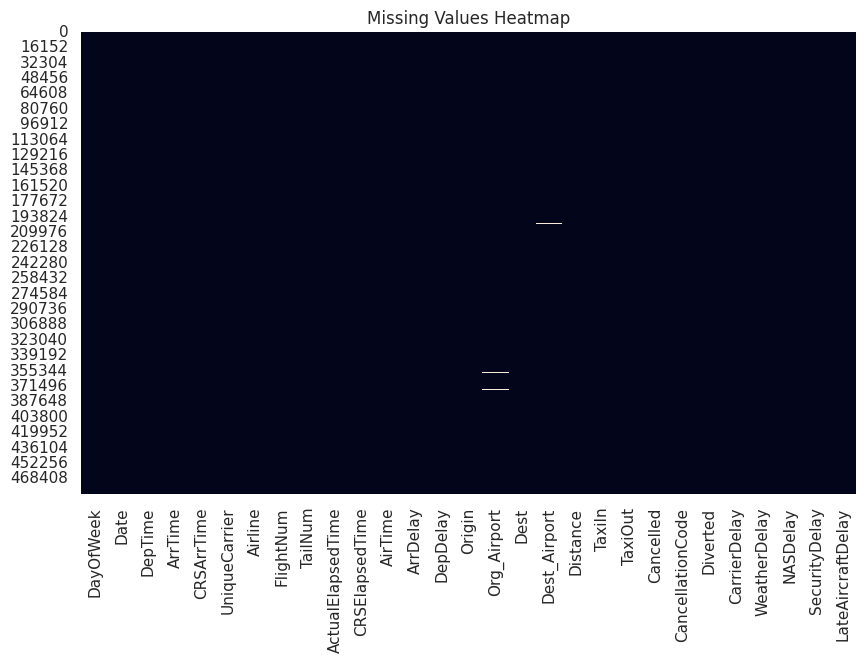

In [65]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Step 5 : Class Distribution

In [66]:
df["is_delayed"] = (df["ArrDelay"] > 15).astype(int)
df["is_delayed"].value_counts()

,count
is_delayed,
1,471530
0,13021


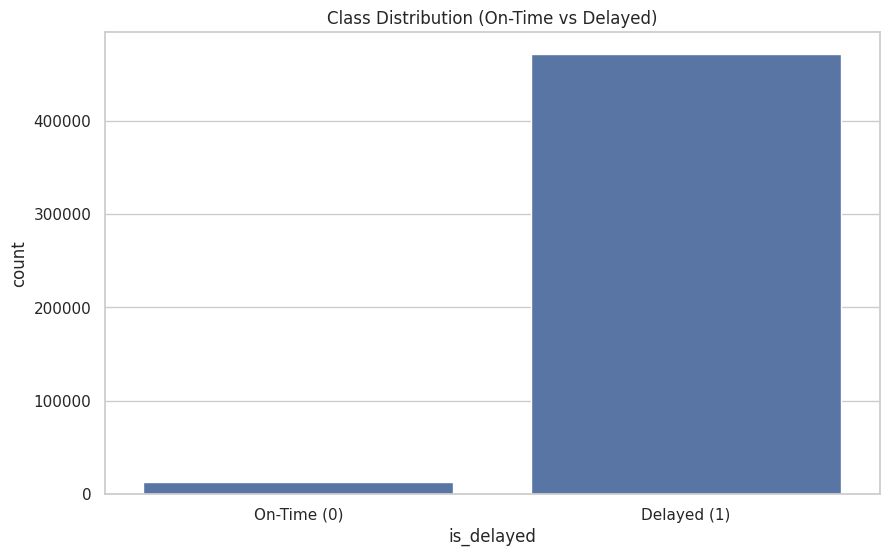

In [67]:
sns.countplot(x="is_delayed", data=df)
plt.title("Class Distribution (On-Time vs Delayed)")
plt.xticks([0, 1], ["On-Time (0)", "Delayed (1)"])
plt.show()

In [68]:
# Percentage Distribution of classes
class_counts = df["is_delayed"].value_counts(normalize=True) * 100
class_counts

,proportion
is_delayed,
1,97.31277
0,2.68723


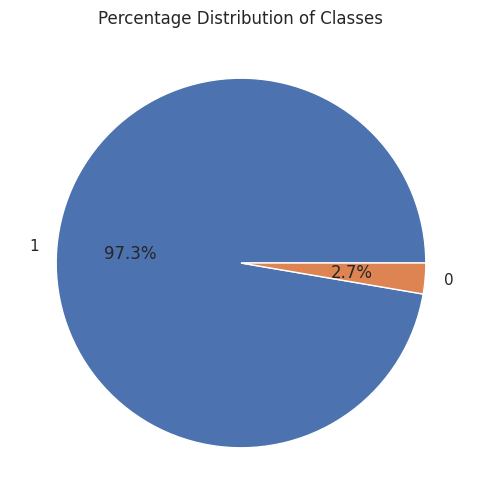

In [69]:
class_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage Distribution of Classes")
plt.ylabel("")
plt.show()

### Step 6 : Distribution of Key Numerical Features

**1. Distance**

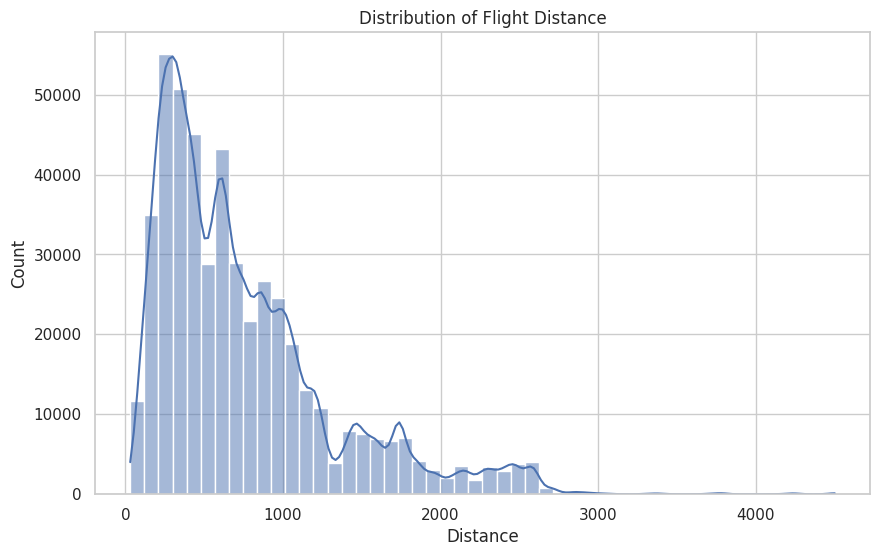

In [70]:
sns.histplot(df["Distance"], bins=50, kde=True)
plt.title("Distribution of Flight Distance")
plt.show()

**2. Departure Time**

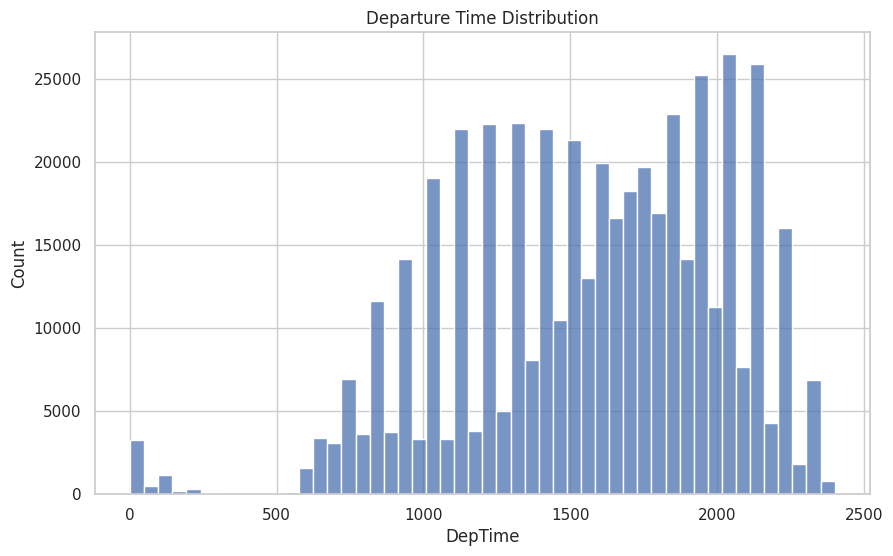

In [71]:
sns.histplot(df["DepTime"], bins=50)
plt.title("Departure Time Distribution")
plt.show()

**3. Arrival Delay**

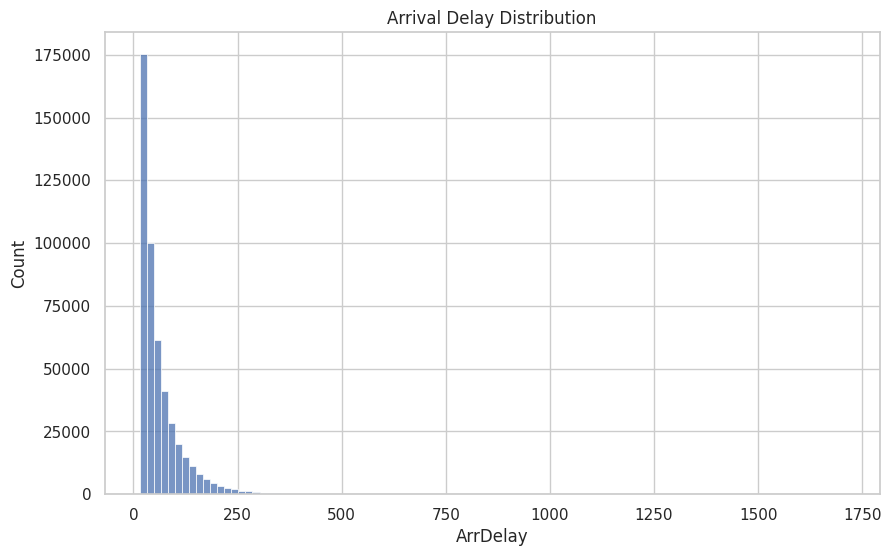

In [72]:
sns.histplot(df["ArrDelay"], bins=100)
plt.title("Arrival Delay Distribution")
plt.show()

### Step 7 : Delay Reason Analysis

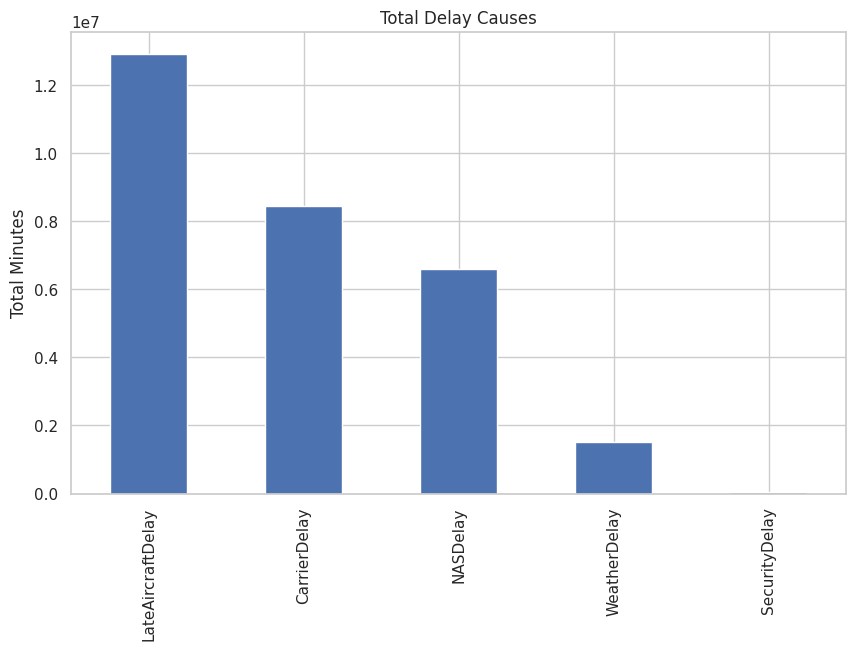

In [73]:
delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

df[delay_cols].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Delay Causes")
plt.ylabel("Total Minutes")
plt.show()


### Step 8 : Correlation Analysis

In [74]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

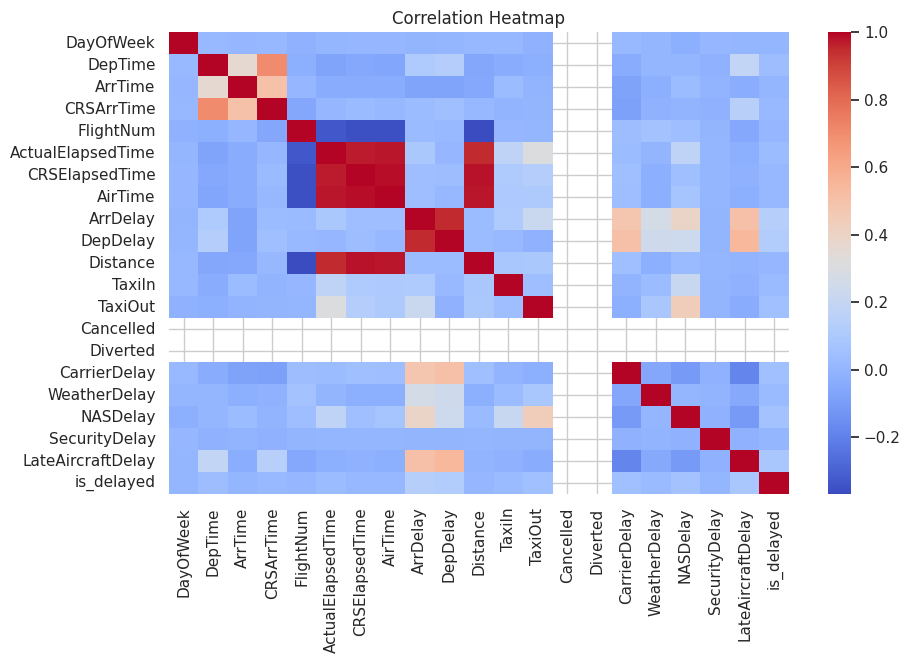

In [75]:
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Step 9 : Distance vs Delay

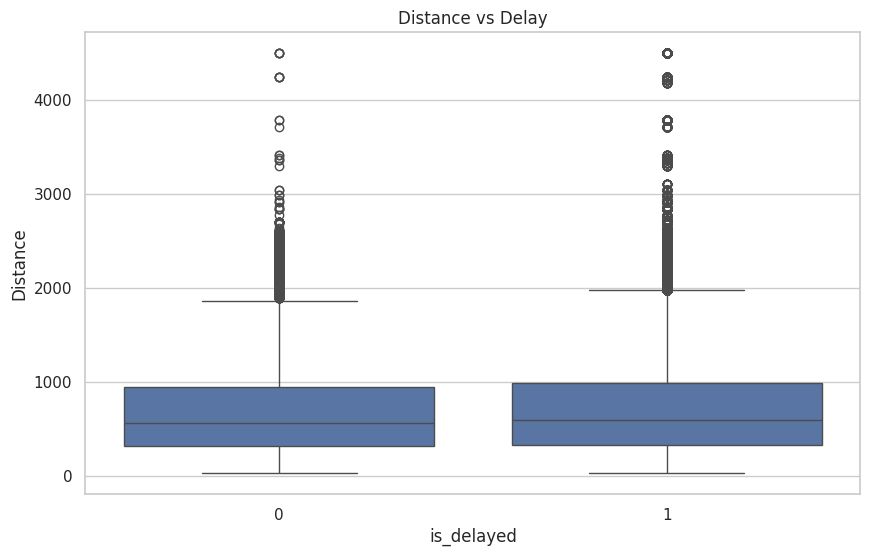

In [76]:
sns.boxplot(x="is_delayed", y="Distance", data=df)
plt.title("Distance vs Delay")
plt.show()

### Step 10 : Airline-wise Delay Distribution

In [77]:
df["Airline"].unique()

array(['Southwest Airlines Co.', 'Skywest Airlines Inc.',
       'United Air Lines Inc.', 'US Airways Inc.', 'Delta Air Lines Inc.',
       'Atlantic Southeast Airlines', 'Frontier Airlines Inc.',
       'Hawaiian Airlines Inc.', 'American Eagle Airlines Inc.',
       'American Airlines Inc.', 'Alaska Airlines Inc.',
       'JetBlue Airways'], dtype=object)

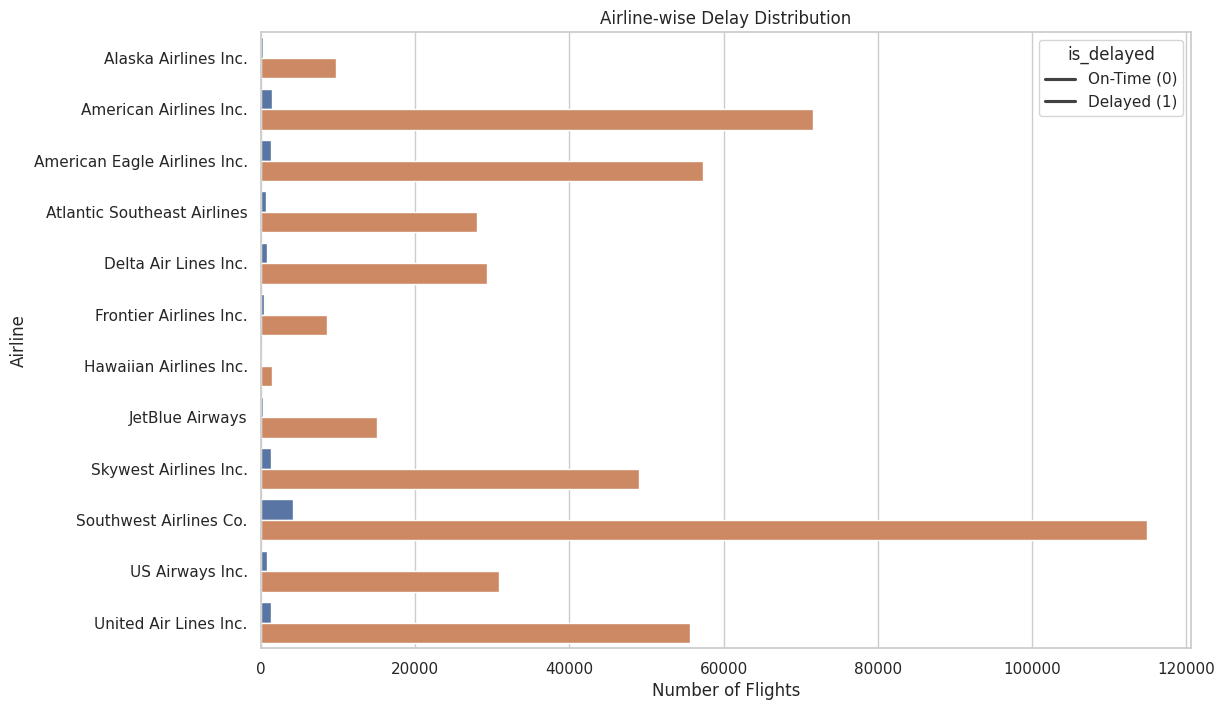

In [78]:
# Count per airline and delay class
airline_delay_counts = df.groupby(["Airline", "is_delayed"]).size().reset_index(name="count")

plt.figure(figsize=(12,8))
sns.barplot(
    data=airline_delay_counts,
    y="Airline",
    x="count",
    hue="is_delayed"
)

plt.title("Airline-wise Delay Distribution")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")
plt.legend(title="is_delayed", labels=["On-Time (0)", "Delayed (1)"])
plt.show()

In [84]:
airline_table = pd.crosstab(
    df["Airline"],
    df["is_delayed"],
    normalize="index"
) * 100

airline_table = airline_table.reset_index()

airline_table.head()


is_delayed,Airline,0,1
0,Alaska Airlines Inc.,2.790000,97.210000
1,American Airlines Inc.,2.014975,97.985025
2,American Eagle Airlines Inc.,2.293093,97.706907
3,Atlantic Southeast Airlines,2.416487,97.583513
4,Delta Air Lines Inc.,2.832561,97.167439


In [85]:
airline_melted = airline_table.melt(
    id_vars="Airline",
    value_vars=[0, 1],
    var_name="is_delayed",
    value_name="percentage"
)

airline_melted.head()


,Airline,is_delayed,percentage
0,Alaska Airlines Inc.,0,2.790000
1,American Airlines Inc.,0,2.014975
2,American Eagle Airlines Inc.,0,2.293093
3,Atlantic Southeast Airlines,0,2.416487
4,Delta Air Lines Inc.,0,2.832561


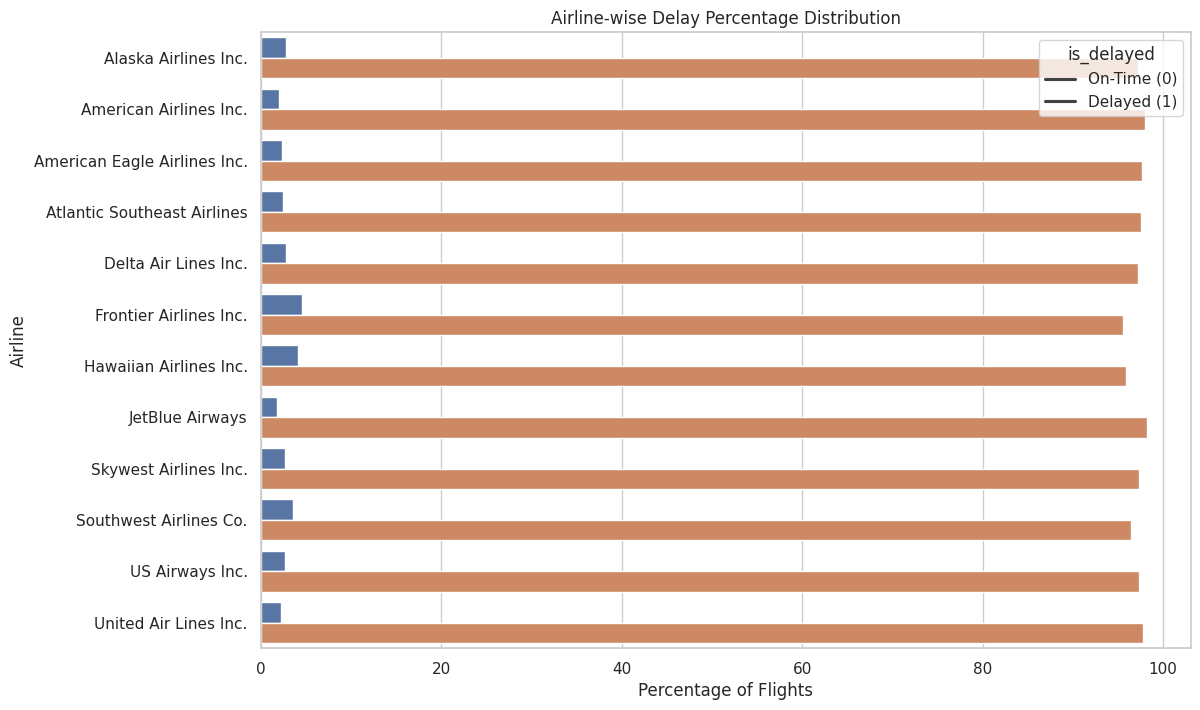

In [86]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=airline_melted,
    y="Airline",
    x="percentage",
    hue="is_delayed"
)

plt.title("Airline-wise Delay Percentage Distribution")
plt.xlabel("Percentage of Flights")
plt.ylabel("Airline")
plt.legend(title="is_delayed", labels=["On-Time (0)", "Delayed (1)"])
plt.show()


### Observation:
- Southwest Airlines Co. has the highest number of delayed flights, likely due to its large flight volume.
- Hawaiian Airlines Inc. and Alaska Airlines Inc. show comparatively better on-time performance with lower delayed counts.
- Overall, most airlines show a significantly higher number of delayed flights compared to on-time flights, indicating strong class imbalance and possible systemic delay patterns in the dataset.
